# Multi Agent Systems: A4 - Multi Agent Greedy Search
#### Deadline: 14-05-2026, 12:00 (noon!)

You may hand in the assignment up to a day late, in which case the assignment grade will be capped at 8. For any extensions please contact the TAs.

Hand in the notebook file on Brightspace, name your file as follows: $\textbf{A4\_yourname.ipynb}$

Studentname: Ella Kemperman \
Studentnumber:  s1119890


$\textit{Don't forget to label your axis and give your graphs titles!}$

### AI Disclaimer

There is no need to use AI such as LLM based chatbots in the assignments (unless
explicitly said otherwise). While the use of AI is not forbidden, whenever AI is used,
you are expected to report what model was used, where was it used in the assignment,
how, and for what purpose. Use the cell below to summarise your AI use. 

**Also note it if you did not use AI! If so, we expect to see absolutely no signs of AI use in your assignment.**

---
#### FILL THIS IN
**Did you use AI for this assignment?** [yes/no]

**Model used:** e.g. *Claude AI*

**Used in:** e.g. *questions 1.1, 3.1*

**Why:** e.g. *To help me create plots and save time scouring documentation*

---

## Part 0 - Diffusion -> belief (1.5 points)
A hiker gets lost in the forest. They are last seen at position $\tau_0 \in \mathbb{R}^2$. The initial condition is modelled with probability $P(\tau,0) = \delta(\tau - \tau_0)$. The hiker starts wandering around. Over long timescales their location looks like:

$$P(\tau,t) = \frac{1}{4\pi D t}
\exp\left(-\frac{|\tau - \tau_0|^2}{4Dt}\right)$$

This represents the initial belief of an agent $b(\tau,t)$ about the target location.

A drone is at position $\tau_i\in\mathbb{R}^2$ and receives a vision-based detection signal. The signal is more reliable when the hiker is close to the drone and becomes less informative further away. When the drone gets a signal, the likelihood says how well each possible traveler location $\tau$ would explain that observation:
$$
P(z_k \mid \tau) \propto 
\exp\left(-\frac{|\tau - \tau_i|^2}{2\sigma_s^2}\right)
$$
With the measurement denoted as $z_k$.

Given the initial belief, show that that the updated belief is also a Gaussian. Use the posterior for the belief update $P(\tau|z_k), and 
\propto P(z_k|\tau)p(\tau)$ and complete the squares to recover a Gaussian form. Explain how the new mean and variance vary with sensor accuracy $\sigma_s$.

The posterior is defined as:
$$P(\tau|z_k) \propto P(z_K|\tau)P(\tau, t)$$
Filling in $P(z_K|\tau)$ and $P(\tau, t)$:
$$P(\tau|z_k) \propto \frac{1}{4\pi D t} \exp\left(-\frac{|\tau - \tau_0|^2}{4Dt}\right) \cdot \exp\left(-\frac{|\tau - \tau_i|^2}{2\sigma_s^2}\right)$$
Combining the exponents:
$$(\tau|z_k) \propto \frac{1}{4\pi D t} \exp\left(-\frac{|\tau - \tau_0|^2}{4Dt} -\frac{|\tau - \tau_i|^2}{2\sigma_s^2}\right)$$
Let's for now ignore the rest of the equation and rewrite the exponent(which I name $C$) by writing as one fraction:
$$C = -\frac{2\sigma_s^2|\tau - \tau_0|^2 + 4Dt|\tau - \tau_i|^2}{8\sigma_s^2Dt}$$
Expanding the squares:
$$C = -\frac{2\sigma_s^2\tau^2 + 2\sigma_s^2\tau_0^2 - 4\sigma_s^2\tau_0\tau + 4Dt\tau^2 + 4Dt\tau_i^2 - 8Dt\tau\tau_i}{8\sigma_s^2Dt}$$
Terms without a $\tau$ are a normalisation constant, therefore, these can be written as a separate fraction irrelevant for showing that this posterior is a Gaussian, the exponent without the constants I name E:
$$E = -\frac{\sigma_s^2\tau^2 - 2\sigma_s^2\tau_0\tau + 2Dt\tau^2 - 4Dt\tau\tau_i}{4\sigma_s^2Dt}$$
Rewriting some more:
$$E = -\frac{(\sigma_s^2 + 2Dt)\tau^2 - (2\sigma_s^2\tau_0 + 4Dt\tau_i)\tau}{4\sigma_s^2Dt}$$
Writing the factor in front of $\tau^2$ into the second factor:
$$E = -\frac{\sigma_s^2 + 2Dt}{4\sigma_s^2Dt}\left(\tau^2 - \frac{2\sigma_s^2\tau_0 + 4Dt\tau_i}{\sigma_s^2 + 2Dt}\tau\right)$$
Factoring out the square from $\tau$
$$E = -\frac{\sigma_s^2 + 2Dt}{4\sigma_s^2Dt}\left(\tau - \frac{\sigma_s^2\tau_0 + 2Dt\tau_i}{\sigma_s^2 + 2Dt}\right)^2 + D$$
Where $D = -\frac{\sigma_s^2 + 2Dt}{4\sigma_s^2Dt}\left(\frac{\sigma_s^2\tau_0 + 2Dt\tau_i}{\sigma_s^2 + 2Dt}\right)^2$, however, it is a constant in the exponent and can therefore again be disregarded. This leaves us with an exponent that is Gaussian again, with 
$$\mu = \frac{\sigma_s^2\tau_0 + 2Dt\tau_i}{\sigma_s^2 + 2Dt},\quad \sigma^2 = \frac{2\sigma_s^2Dt}{\sigma_s^2 + 2Dt}$$
With $\mu$ the mean, $\sigma^2$ the variance.

The mean and variance seem quite independent of the sensor accuracy. Only they are only significantly influenced at low accuracy near $0$. For higher accuracies, the mean and variance asymptotically approach a value determined by the other variables in the equation $D$, $t$, $\tau_i$, $\tau_0$ 

---
# Multi agent cooperation

The previous assignment introduced you to a single agent that searches for a lost target using its belief. This belief was updated at every timestep using the probability of non-detection of the agents current position. This assignment expands on that. The first part of the assignment asks you to implement the agent in a modular way, and use that implementation to expand to a multi-agent search (greedy, 1-step, discrete, no communication). The second part of the assignment will then ask you to implement a new search algorithm, in which the agents share their belief. Finally, you will look at what happens when you start to introduce noise to the system.

Note that you should be able to recycle a lot of your code from the previous assignment into the first part of this assignment.

## Part 1 - Multiagent search greedy 1 step discrete no communication

In [1]:
# Numpy numerical library -> import [library] as name
import numpy as np

# Plotting libraries -> matplotlib
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D # 3D plots
from matplotlib import cm # Color maps
import matplotlib.colors as mcolors # colours for the different agents

# prior belief
from scipy.stats import multivariate_normal

# Matrix auxiliary functions
import numpy.matlib

# System libraries
import os
import sys

#### Observation model reminder

Please use the same values for the sensor for all exercises.

In [2]:
# example sensor values
Pdmax = 0.8 # Max range sensor
dmax = 4 # Max distance
sigma = 0.7 # Sensor spread (standard deviation)

#### Agent class (2 points)
Let's first code the agent as a python class to do a modular programming approach that will aid in the design of the final algorithm. Use assignment 3 to figure out how to finish the code below. The color variable in the constructor represents the color of the track of the agent.


In [9]:
class Agent:

    # Constructor
    def __init__(self, 
                 i, 
                 state=np.array([0.,0.]), 
                 map_size = np.array([40, 40]), 
                 bk = np.ones((40, 40))*(1./1600), 
                 color='r', 
                 delta = 0.5, 
                 Pdmax=Pdmax, 
                 dmax=dmax, 
                 sigma=sigma
                ):
        
        self.id = i  # Create an instance variable
        self.map_size = map_size
        self.width, self.height = map_size[0], map_size[1]
        
        # Environment. Compute the grid into one vector as we did in the previous sections 
        x = y = np.arange(0, self.width) # This only works if both have the same size
        self.X, self.Y = np.meshgrid(x, y) # generate grid
        self.map = np.zeros((self.width, self.height))
        
        # belief
        self.bk = bk

        # Agent params
        self.x = state
        self.track = self.x.T # Stores all positions. Aux variable for visualization of the agent path
        self.height_plot = 0.1
        
        # add extra agents params 
        self.movement_directions = np.array([
            [0, 0],
            [0, delta],
            [delta, 0],
            [0, -delta],
            [-delta, 0],
            [delta, delta],
            [delta, -delta],
            [-delta, delta],
            [-delta, -delta]
        ])
        self.color = color

        # Sensor params 
        self.Pdmax = Pdmax
        self.dmax = dmax
        self.sigma = sigma

    # get id
    def get_id(self):
        return self.id

    # compute discrete forward states 1 step ahead
    # TODO
    def forward(self):
        randomised = np.random.permutation(self.movement_directions)
        fs = randomised + self.x
        return fs[np.logical_and(np.logical_and(0 < fs[:, 0], fs[:, 0] < self.width), np.logical_and(0 < fs[:, 1], fs[:, 1] < self.height))]
        
    # computes pnd of forward states
    # TODO
    def nodetect_observation(self, pos):
        def inner(x, y):
            X = np.array([x, y])
            d = np.sum((pos - X)**2)**0.5
            return 1 - self.Pdmax * np.exp(-self.sigma * (d / self.dmax)**2)
        return np.vectorize(inner)(self.X, self.Y)
        
    # computes utility of states
    # TODO
    def utility(self, fs):
        # compute cost funtion J of all potential forward states (brute force method)
        p_d = self.nodetect_observation(fs)
        return np.sum(p_d * self.bk)

    def next_best_state(self):
        next_states = self.forward()
        utilities = np.vectorize(lambda next_state: self.utility(next_state), signature="(m) -> ()")(next_states)
        return next_states[np.argmin(utilities)]
      
    # simulate agent next state
    def next(self, state):
        self.x = state
        self.track = np.vstack((self.track, self.x))

    # update belief with observation at state self.x
    # TODO
    def update_belief(self):
        update = self.nodetect_observation(self.x)
        belief = self.bk * update
        self.bk = belief / np.sum(belief)
      
    def plot(self, ax):
        # plot contour of the P(\tau) -> self.bk
        cset = ax.contourf(self.X, self.Y, self.bk, zdir='z', offset=-0.005, cmap=cm.viridis, alpha=0.5)

        # plot agent trajectory, self.track
        ax.plot(self.track[:, 0], self.track[:, 1], np.ones(self.track.shape[0]) * self.height_plot, '-', linewidth=2, color=self.color);
        ax.plot([self.track[-1, 0], self.track[-1, 0]], [self.track[-1, 1], self.track[-1, 1]], [self.height_plot, 0], 'ko-', linewidth=2);

        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('P')


        # Adjust the limits, ticks and view angle
        ax.set_zlim(0, 0.12)
        ax.view_init(27, -21)

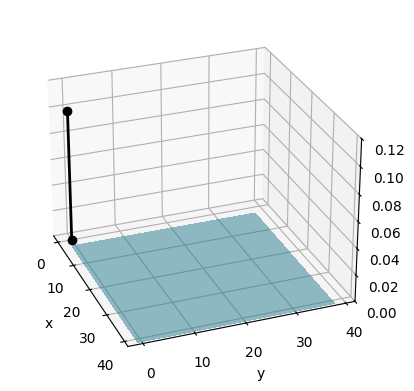

In [4]:
# plot in notebook
%matplotlib inline 

# TO TEST YOUR CODE
# Create agent 0, move it to position (0,0) and plot it
a = Agent(0)
a.next(np.array([0,0]))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
a.plot(ax)

### Helper functions (0.5 points)

Please finish the following two helper functions below. You will use the bivariate Gaussian again as the initial belief of the agents. You can use the second function to randomly select an agent's startating position, given a world size.

In [5]:
def bivariate_gaussian(w, h, mu, sigma):
    """
    Generate the pdf of a bivariate gaussian distribution in a specific world

    Parameters
    ----------
    w : int
        the width of the world
    h : int
        the height of the world
    mu : array of integers
        the mean of the gaussian 
    sigma : array of integers
        the covariance of the gaussian

    Returns
    -------
    array of integers
        the bivariate gaussian

    """
    def inner(x, y):
        X = np.array([x, y])
        return (2 * np.pi)**(-sigma.shape[0] / 2) * np.linalg.det(sigma)**(-0.5) * np.exp(-0.5 * (X - mu).T @ np.linalg.inv(sigma) @ (X - mu))

    x = np.arange(0, width)
    y = np.arange(0, height) # This only works if both have the same size
    X, Y = np.meshgrid(x, y) # generate grid
    return np.vectorize(inner)(X, Y)

def random_agent_start_pos(w, h):
    """
    Randomly selects the starting position of an agent in a specific world

    Parameters
    ----------
    w : int
        width of the world
    h : int
        height of the world

    Returns
    -------
    array of 2 integers
        a position in the world

    """
    # TODO
    return np.random.randint(np.array([w, h]))

### Create the search loop (2 points)

With the agent class defined, it is now time to actually implement multi-agent search. Use the following skeleton code to implement a loop that allows N agents to search in a predefined world, $\textit{at the same time}$. Every agent has its own belief, so they are all acting independently. Use the bivariate Gaussian as the initial belief, and start every agent at a random position within the world. Use the helper functions above. Make sure that every agent gets a different colour, so that they can be separated more easily in the plot. Ensure your code works for different values of **nagents**, without having to change the rest of the code. 

When run, a new window should open that shows the agents moving through the world, with the contour of all different beliefs plotted below them. You might need to reduce the transparacy of the contours to make them all visible.

***NOTE***: The animation plotting does not work when you are using Google Colab, as Colab only supports *matplotlib inline*. If you are unable to use another environment (like Jupyter), you will need to adapt the plotting code so that it works in Colab.

Using matplotlib backend: inline
-------------------------------------------------

> M-Agents search 2D (1 n-step ahead no comm)



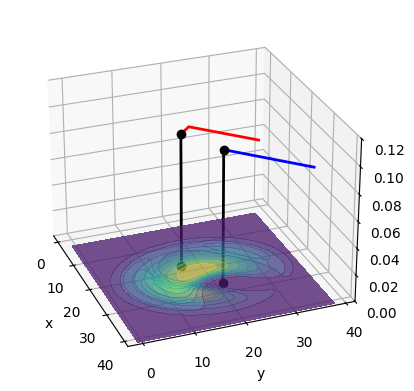

In [10]:
# allow animations to work within notebook
%matplotlib

print('-------------------------------------------------\n');
print('> M-Agents search 2D (1 n-step ahead no comm)\n')

# Define parameters
width = height = 40 # Size of the environment
nagents = 2
mu = np.array([width/2., height/2.])# center point
Sigma = np.array([[40,0],[0,60]]) # Bimodal covariance with no dependence.
belief = bivariate_gaussian(width, height, mu, Sigma)

# Create list of agents
colors = ["r", "b"]
agents = [Agent(i, state=random_agent_start_pos(width, height), map_size = np.array([width, height]), bk=belief, color=colors[i]) for i in range(nagents)]

# Global plot for animations
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Start algorithm|
ite = 0  # iteration count
nite = 25  # number of iterations
found = 0  # target found (this parameter will not be used in the assignments as we assume that it is never found)

## start search
while not found and ite < nite:
    for agent in agents:
        next_state = agent.next_best_state()
        agent.next(next_state)
        agent.update_belief()
        
    # iteration count
    ite += 1

for agent in agents:
    agent.plot(ax)

## Part 2 - Multiagent search greedy 1 step discrete common belief (2 points)

Now, we go one step further, and allow the agents to communicate. We will do this by defining a common global belief that all agents share. After all agents moved according to this common belief, you update this belief using all the new information (so the probability of non-detection for every agent's position). You can define a new function for this (within or outside the agent class).

The output should again be an animation of the agents, but now only the contour of the common belief should be plotted below.

In [64]:
# allow animations to work within notebook
%matplotlib

print('-------------------------------------------------\n');
print('> M-Agents search 2D (1 n-step ahead common belief)\n')

nagents = 2
# Create environment

# Create agents

# Global plot for animations
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
plt.ion()

# Start algorithm
ite = 0  # iteration count
nite = 25  # number of iterations
found = 0  # target found (this parameter will not be used in the assignments as we assume that it is never found)

# Initialize common belief  bk = prior probability map p(\tau)

## start search
while not found and ite < nite:

    # Compute next best state for each agent given the common belief
    
    # Update common belief
            
    # Plot every agent and the contour of the common belief
        
    # plot
    plt.draw()
    ax.cla()
    plt.pause(0.1)  # animation

    # iteration count
    ite += 1

Using matplotlib backend: notebook
-------------------------------------------------

> M-Agents search 2D (1 n-step ahead common belief)



<IPython.core.display.Javascript object>

## Part 3 - Introducing Noise

### NoisyAgent (1.5 points)

The systems you implement above assume that your agents receive perfect information from their sensors, and move exactly where you tell them to move, they're fully deterministic. In a real world situation this might naturally not be the case. Below we introduce a new class **NoisyAgent**, which inherits from the previously defined **Agent** class. 

We ask you to finish the class below, and redefine the next() function, such that when you would set the next position of the agent, there is a possibiltiy that something goes wrong and the agent accidentaly moves to different state than intended. We leave it up to you how to implement this, but keep two things in mind:
* There should be a higher probability that the agent moves close to its intended location. Meaning that if it intends to go North, it is more likely to suddenly head Northeast or Northwest than South. The exact probabilities are up to you.
* The noise intensity should be influenced by a parameter you pass when creating an instantation of the agent class.

Once you have finished the agent class, write the search loop again. Use a swarm of agents with different noise intensities, at least one should not be influenced by noise, while another one should completely devolve into stochastic behaviour. You can use the common believe again.

*Note that although the introduction of noise will naturally decrease the effectiveness of your utility function, there is currently no need to adapt it to deal with the noise. You can keep the one previously defined, which assumes deterministic behaviour.*

In [ ]:
class NoisyAgent(Agent):

    def __init__(self, i, state=np.array([0., 0.]), map_size=np.array([40, 40]),
                 bk=np.ones(1600)*(1./1600), color='r', noise_intensity=???): # <--------- change as you wish
        
        # initialize parent class
        super().__init__(i, state, map_size, bk, color)
        
        # additional noise parameter
        self.noise_intensity = noise_intensity

    # override next state function with new noisy function
    def next(self, state):
        # TODO
        
        self.x = ...
        self.track = ...

In [ ]:
# allow animations to work within notebook
%matplotlib

### NOISY SEARCH LOOP

### Reflection (0.5 points)

How does changing the noise intensity influence the trajectories of the agents? Compare them with what you remember from the (A)BP behaviour from the first two assignments.

**YOUR TEXT ANSWER HERE**